# NLP Case study 1 

## NB model with Unigram+CountVectors	 

**Config of the model trained**

Train Time = 0.18 seconds	

**Training Data Check**	

Confusion Matrix Built - Yes

F1 Score for Positive = 0.9321

F1 Score for Negative = 0.8573
AUC plotted - Yes

AUC = 0.9630	

Accuracy computed - Yes	

Accuracy = 0.8856 

**Feature Engg**

Categorical/Numerical Features Added - Yes	

Name 2 features added - review_length and word_count 

Cross Validation - Yes (0.80)	 	 	 
 
**Interpretability**	

Interpretability Implemented? - Yes, Local	

2 interesting findings? 

-world cloud for positive and negative reviews

-Top 10 positive and negative reviews 
                 
**Testing Data Check** 	

Confusion Matrix Built - Yes

F1 Score for Positive = 0.9005

F1 Score for Negative = 0.7639

AUC plotted - Yes	

AUC = 0.8277

Accuracy computed - Yes

Accuracy = 0.8205

In [5]:
import random
import json
import pandas as pd

# File path
file_path = '/Users/maaz/Desktop/NLP Assignment/Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json'

# Function to sample data from JSON
def sample_json(file_path, sample_size):
    sampled_data = []
    with open(file_path, 'r') as file:
        # Read all lines from the file
        lines = file.readlines()
        # Randomly sample lines
        sampled_lines = random.sample(lines, sample_size)
        for line in sampled_lines:
            # Parse each line as JSON and extract necessary fields
            record = json.loads(line)
            sampled_data.append({"text": record["text"], "stars": record["stars"]})
    return pd.DataFrame(sampled_data)

# Get a random sample of 10,000 rows
sample_size = 10000
sampled_data = sample_json(file_path, sample_size)

# Preview the sample
print(sampled_data.head())

# Save the sample to a CSV file for easier reuse (optional)
sampled_data.to_csv('/Users/maaz/Desktop/NLP Assignment/yelp_sample.csv', index=False)



                                                text  stars
0  I hate to say it. I really, really do.\nThe Ox...    3.0
1  Gray Fox Realty has demonstrated their ability...    5.0
2  Local here. Sorry to leave this review but the...    2.0
3  We make it a point to visit NOLA once or twice...    4.0
4  Bomb.com \nThey have the most Delicious soups,...    5.0


## 1. Naive Bayes model using Count Vectors for Unigram

**Build the following models to predict whether a given review is Positive (4 or 5 stars), Negative (2 or less stars) or Neutral on the Yelp Dataset**

In [324]:
# import all necessary libraries

import pandas as pd 
import numpy as np 
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import time
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Download necessary NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /Users/maaz/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/maaz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/maaz/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [326]:
# To display all the text 

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [328]:
## import sample dataset

df = pd.read_csv('yelp_sample.csv')

## display top 5 rows 

df.head()

,text,stars
0,"I hate to say it. I really, really do.\nThe Oxford Exchange is a gorgeous space that is doing some very big things for Tampa. We have needed something like this for quite some time and here it is.\nThe assistance I've received from all retail vendors has always been top notch, with no complaints.\nThis review is specifically for the restaurant which, while still lovely, has a less than stellar offering at an expensive price tag. I have no problem throwing down $25 for lunch, particularly if the food is amazing and you are getting an experience that justifies the cost. However, the food is so-so and there is a quality of service that is lacking from staff that leaves customers waiting or checking a clock. \nIt's one of my very favorite spots in Tampa, particularly with out of town friend visiting. Just be very mindful of getting a spot in the restaurant if you have any kind of time sensitivity.",3.0
1,"Gray Fox Realty has demonstrated their ability to offer a unique platform for sellers to list and sell their properties in this everchanging Real Estate market. As a recent customer of Gray Fox Realty, the constant guidance and communication received from the staff through the sell process was extremely helpful to keep us on track to close on time and prepare our home for the new buyers. Mike and Joey from Gray Fox Realty created tools through automation, applications and videos to guide the seller on each step to prepare for upcoming events such as showings, inspections and transacting documents. Gray Fox Realty provides full service throughout your sale with a unique compensation platform for their services that saves you the seller by retaining more of your equity. Gray Fox Realty provides services to both sellers and buyers. We thank them for a great experience and highly recommend Gray Fox Realty for your Real Estate needs.",5.0
2,Local here. Sorry to leave this review but the food was very disappointing. We had the mushroom tacos which were very bland. Two step with brisket and pulled pork were just ok. Tender but bland AF. The sides -fries and cucumber salad were soggy and bland. Hot sauce options were basic and bland. If you want flavorful bbq I'd recommend urban brew and bbq down the street instead. If you have time to drive to Dunedin check out the Dunedin smokehouse.,2.0
3,"We make it a point to visit NOLA once or twice each year and we're always looking for new places to eat. So glad we found Dreamy Weenies! Fresh made buns, variety of dogs, and that candied yam molasses for the sweet potato fries is to die for! My boyfriend and I ordered 2 dogs, an order of fries, and two drinks for $20. We will definitely be returning!",4.0
4,"Bomb.com \nThey have the most Delicious soups, \nand I Love the Quinoa Avocado Salad!\nBread & Panini's are very good too as well as the beer.\nGreat wifi & chill vibes.",5.0


In [330]:
def assign_sentiment(stars):
    if stars >= 4:
        return 'Positive'
    elif stars <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['stars'].apply(assign_sentiment)


In [332]:
df.head()

,text,stars,sentiment
0,"I hate to say it. I really, really do.\nThe Oxford Exchange is a gorgeous space that is doing some very big things for Tampa. We have needed something like this for quite some time and here it is.\nThe assistance I've received from all retail vendors has always been top notch, with no complaints.\nThis review is specifically for the restaurant which, while still lovely, has a less than stellar offering at an expensive price tag. I have no problem throwing down $25 for lunch, particularly if the food is amazing and you are getting an experience that justifies the cost. However, the food is so-so and there is a quality of service that is lacking from staff that leaves customers waiting or checking a clock. \nIt's one of my very favorite spots in Tampa, particularly with out of town friend visiting. Just be very mindful of getting a spot in the restaurant if you have any kind of time sensitivity.",3.0,Neutral
1,"Gray Fox Realty has demonstrated their ability to offer a unique platform for sellers to list and sell their properties in this everchanging Real Estate market. As a recent customer of Gray Fox Realty, the constant guidance and communication received from the staff through the sell process was extremely helpful to keep us on track to close on time and prepare our home for the new buyers. Mike and Joey from Gray Fox Realty created tools through automation, applications and videos to guide the seller on each step to prepare for upcoming events such as showings, inspections and transacting documents. Gray Fox Realty provides full service throughout your sale with a unique compensation platform for their services that saves you the seller by retaining more of your equity. Gray Fox Realty provides services to both sellers and buyers. We thank them for a great experience and highly recommend Gray Fox Realty for your Real Estate needs.",5.0,Positive
2,Local here. Sorry to leave this review but the food was very disappointing. We had the mushroom tacos which were very bland. Two step with brisket and pulled pork were just ok. Tender but bland AF. The sides -fries and cucumber salad were soggy and bland. Hot sauce options were basic and bland. If you want flavorful bbq I'd recommend urban brew and bbq down the street instead. If you have time to drive to Dunedin check out the Dunedin smokehouse.,2.0,Negative
3,"We make it a point to visit NOLA once or twice each year and we're always looking for new places to eat. So glad we found Dreamy Weenies! Fresh made buns, variety of dogs, and that candied yam molasses for the sweet potato fries is to die for! My boyfriend and I ordered 2 dogs, an order of fries, and two drinks for $20. We will definitely be returning!",4.0,Positive
4,"Bomb.com \nThey have the most Delicious soups, \nand I Love the Quinoa Avocado Salad!\nBread & Panini's are very good too as well as the beer.\nGreat wifi & chill vibes.",5.0,Positive


## Text Cleaning

In [335]:
# Convert to lowercase
def to_lowercase(text):
    return text.lower()

# Remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Remove stop words
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    tokens = word_tokenize(text)
    return ' '.join([word for word in tokens if word not in stop_words])

# Remove digits
def remove_digits(text):
    return re.sub(r'\d+', '', text)

# Tokenize text
def tokenize_text(text):
    return word_tokenize(text)

# Lemmatization
lemmatizer = WordNetLemmatizer()
def apply_lemmatization(text):
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

In [337]:
# Apply cleaning functions
df['cleaned_text'] = df['text'].apply(to_lowercase)\
                               .apply(remove_punctuation)\
                               .apply(remove_digits)\
                               .apply(remove_stopwords)\
                               .apply(apply_lemmatization)

In [338]:
df.head()

,text,stars,sentiment,cleaned_text
0,"I hate to say it. I really, really do.\nThe Oxford Exchange is a gorgeous space that is doing some very big things for Tampa. We have needed something like this for quite some time and here it is.\nThe assistance I've received from all retail vendors has always been top notch, with no complaints.\nThis review is specifically for the restaurant which, while still lovely, has a less than stellar offering at an expensive price tag. I have no problem throwing down $25 for lunch, particularly if the food is amazing and you are getting an experience that justifies the cost. However, the food is so-so and there is a quality of service that is lacking from staff that leaves customers waiting or checking a clock. \nIt's one of my very favorite spots in Tampa, particularly with out of town friend visiting. Just be very mindful of getting a spot in the restaurant if you have any kind of time sensitivity.",3.0,Neutral,hate say really really oxford exchange gorgeous space big thing tampa needed something like quite time assistance ive received retail vendor always top notch complaint review specifically restaurant still lovely le stellar offering expensive price tag problem throwing lunch particularly food amazing getting experience justifies cost however food soso quality service lacking staff leaf customer waiting checking clock one favorite spot tampa particularly town friend visiting mindful getting spot restaurant kind time sensitivity
1,"Gray Fox Realty has demonstrated their ability to offer a unique platform for sellers to list and sell their properties in this everchanging Real Estate market. As a recent customer of Gray Fox Realty, the constant guidance and communication received from the staff through the sell process was extremely helpful to keep us on track to close on time and prepare our home for the new buyers. Mike and Joey from Gray Fox Realty created tools through automation, applications and videos to guide the seller on each step to prepare for upcoming events such as showings, inspections and transacting documents. Gray Fox Realty provides full service throughout your sale with a unique compensation platform for their services that saves you the seller by retaining more of your equity. Gray Fox Realty provides services to both sellers and buyers. We thank them for a great experience and highly recommend Gray Fox Realty for your Real Estate needs.",5.0,Positive,gray fox realty demonstrated ability offer unique platform seller list sell property everchanging real estate market recent customer gray fox realty constant guidance communication received staff sell process extremely helpful keep u track close time prepare home new buyer mike joey gray fox realty created tool automation application video guide seller step prepare upcoming event showing inspection transacting document gray fox realty provides full service throughout sale unique compensation platform service save seller retaining equity gray fox realty provides service seller buyer thank great experience highly recommend gray fox realty real estate need
2,Local here. Sorry to leave this review but the food was very disappointing. We had the mushroom tacos which were very bland. Two step with brisket and pulled pork were just ok. Tender but bland AF. The sides -fries and cucumber salad were soggy and bland. Hot sauce options were basic and bland. If you want flavorful bbq I'd recommend urban brew and bbq down the street instead. If you have time to drive to Dunedin check out the Dunedin smokehouse.,2.0,Negative,local sorry leave review food disappointing mushroom taco bland two step brisket pulled pork ok tender bland af side fry cucumber salad soggy bland hot sauce option basic bland want flavorful bbq id recommend urban brew bbq street instead time drive dunedin check dunedin smokehouse
3,"We make it a point to visit NOLA once or twice each year and we're always looking for new places to eat. So glad we found Dreamy Weenies

In [339]:
# Assign features (cleaned text) and target (sentiment)
X = df['cleaned_text']  # Preprocessed text
y = df['sentiment']     # Sentiment (Positive, Negative, Neutral)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Training Time

In [344]:
# Start time to measure training duration
start_time = time.time()

# Initialize CountVectorizer for Unigram
vectorizer = CountVectorizer(ngram_range=(1, 1),max_features=10000)  # Unigram

# Transform the text into Count Vectors
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)

# Initialize the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_vectors, y_train)

# Measure training time
train_time = time.time() - start_time
print(f"Training Time: {train_time:.2f} seconds")


Training Time: 0.18 seconds


In [346]:
# Make predictions on the test set
y_pred = nb_model.predict(X_test_vectors)

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

    Negative       0.74      0.79      0.76       452
     Neutral       0.44      0.30      0.36       212
    Positive       0.89      0.91      0.90      1336

    accuracy                           0.82      2000
   macro avg       0.69      0.67      0.67      2000
weighted avg       0.81      0.82      0.81      2000

Accuracy Score: 0.8205
Confusion Matrix:
 [[ 356   45   51]
 [  44   63  105]
 [  80   34 1222]]


## Example new review

In [349]:
new_reviews = ["Loved this tour! I grabbed a groupon and the price was great. It was the perfect way to explore New Orleans for someone who'd never been there before and didn't know a lot about the history of the city. Our tour guide had tons of interesting tidbits about the city, and I really enjoyed the experience. Highly recommended tour. I actually thought we were just going to tour through the cemetery, but she took us around the French Quarter for the first hour, and the cemetery for the second half of the tour. You'll meet up in front of a grocery store (seems strange at first, but it's not terribly hard to find, and it'll give you a chance to get some water), and you'll stop at a visitor center part way through the tour for a bathroom break if needed. This tour was one of my favorite parts of my trip!"]
# Preprocess and transform new reviews
new_reviews_vectors = vectorizer.transform(new_reviews)

# Predict sentiment
new_predictions = nb_model.predict(new_reviews_vectors)

print(new_predictions)  # Output: ['Positive', 'Negative', 'Neutral']


['Positive']


## Training data check and Evaluation 

In [352]:
# Compute F1 Score for all classes
f1_train = f1_score(y_train, y_train_pred, average='weighted')
print(f"Weighted F1 Score (Train): {f1_train:.4f}")


Weighted F1 Score (Train): 0.8780


In [354]:
f1_pos_train = f1_score(y_train, y_train_pred, labels=['Positive'], average='macro')
f1_neg_train = f1_score(y_train, y_train_pred, labels=['Negative'], average='macro')
f1_neu_train = f1_score(y_train, y_train_pred, labels=['Neutral'], average='macro')

print(f"F1 Score for Positive (Train): {f1_pos_train:.4f}")
print(f"F1 Score for Negative (Train): {f1_neg_train:.4f}")
print(f"F1 Score for Neutral (Train): {f1_neu_train:.4f}")


F1 Score for Positive (Train): 0.9321
F1 Score for Negative (Train): 0.8573
F1 Score for Neutral (Train): 0.5726


In [356]:
# Get predicted probabilities for all classes
y_train_prob = nb_model.predict_proba(X_train_vectors)

# Compute AUC for each class using 'ovr' or 'ovo'
auc_train = roc_auc_score(y_train, y_train_prob, multi_class='ovr', average='weighted')
print(f"AUC Score (Train): {auc_train:.4f}")


AUC Score (Train): 0.9630


In [388]:
from sklearn.metrics import accuracy_score

# Predict the class labels for training data
y_train_pred = nb_model.predict(X_train_vectors)
y_test_pred = nb_model.predict(X_test_vectors)

# Calculate accuracy for both training and testing data
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Print the accuracy scores
print(f"Accuracy Score (Train): {accuracy_train:.4f}")
print(f"Accuracy Score (Test): {accuracy_test:.4f}")


Accuracy Score (Train): 0.8856
Accuracy Score (Test): 0.8205


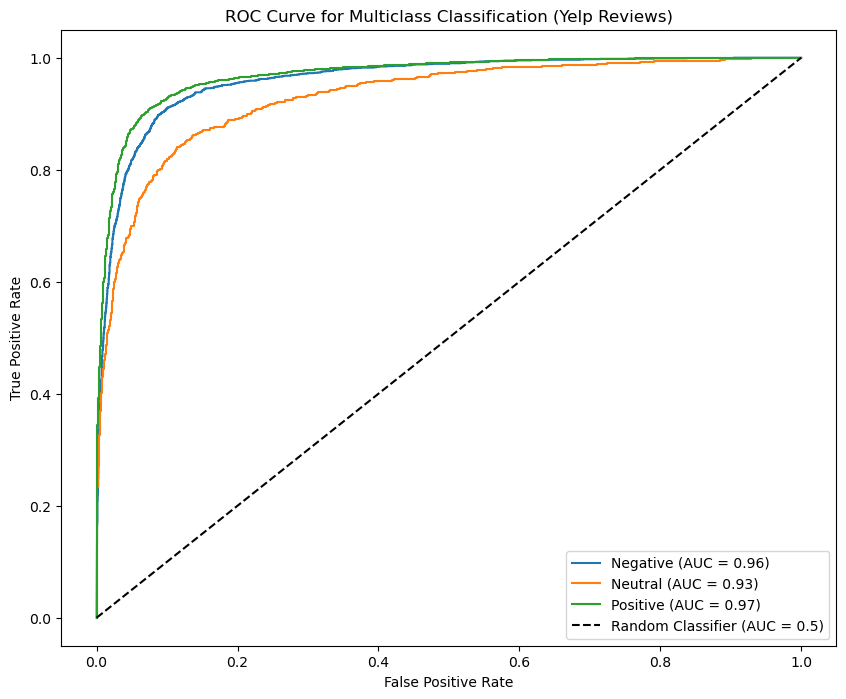

In [358]:
# Get predicted probabilities for each class
y_train_prob = nb_model.predict_proba(X_train_vectors)

# Map classes to indices: Assuming 0=Negative, 1=Neutral, 2=Positive
class_labels = ['Negative', 'Neutral', 'Positive']

# Initialize the plot
plt.figure(figsize=(10, 8))

# Loop through each class and compute ROC curve
for i, label in enumerate(class_labels):
    # Compute the ROC curve for each class
    fpr, tpr, _ = roc_curve(y_train == label, y_train_prob[:, i])
    
    # Compute AUC for the class
    auc_score = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass Classification (Yelp Reviews)')
plt.legend(loc='lower right')

# Show the plot
plt.show()


### Testing Data Check and Evaluation

In [361]:
# Compute F1 Score for all classes
f1_test = f1_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score (Test): {f1_test:.4f}")

Weighted F1 Score (Test): 0.8119


In [363]:
f1_pos_test = f1_score(y_test, y_pred, labels=['Positive'], average='macro')
f1_neg_test = f1_score(y_test, y_pred, labels=['Negative'], average='macro')
f1_neu_test = f1_score(y_test, y_pred, labels=['Neutral'], average='macro')

print(f"F1 Score for Positive (Test): {f1_pos_test:.4f}")
print(f"F1 Score for Negative (Test): {f1_neg_test:.4f}")
print(f"F1 Score for Neutral (Test): {f1_neu_test:.4f}")

F1 Score for Positive (Test): 0.9005
F1 Score for Negative (Test): 0.7639
F1 Score for Neutral (Test): 0.3559


In [365]:
# Get predicted probabilities for all classes
y_test_prob = nb_model.predict_proba(X_test_vectors)

# Compute AUC for each class using 'ovr' or 'ovo'
auc_train = roc_auc_score(y_test, y_test_prob, multi_class='ovr', average='weighted')
print(f"AUC Score (Test): {auc_test:.4f}")


AUC Score (Test): 0.8277


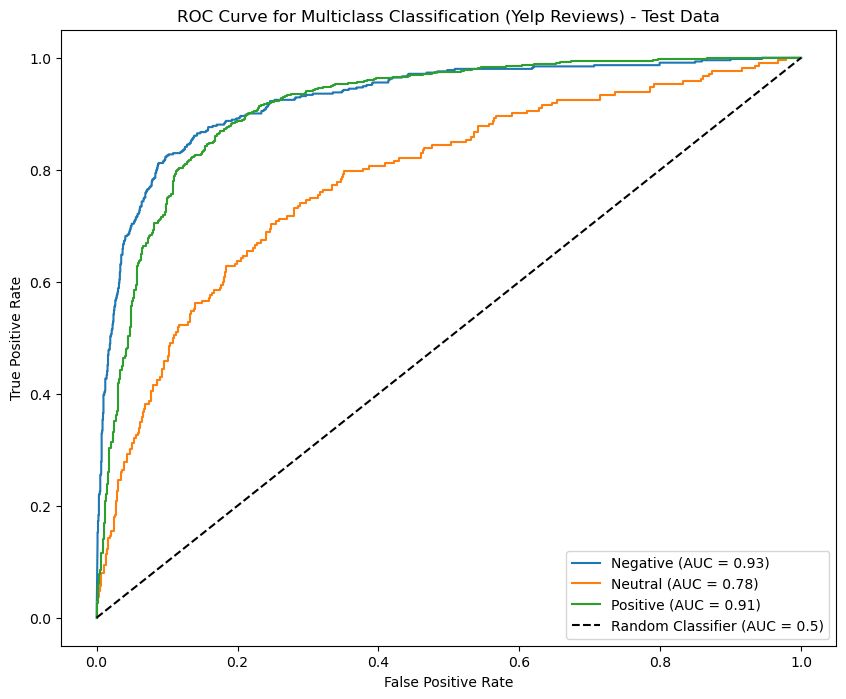

In [367]:
# Get predicted probabilities for testing data
y_test_prob = nb_model.predict_proba(X_test_vectors)

# Initialize the plot
plt.figure(figsize=(10, 8))

# Loop through each class and compute ROC curve
for i, label in enumerate(class_labels):
    # Compute the ROC curve for each class
    fpr, tpr, _ = roc_curve(y_test == label, y_test_prob[:, i])
    
    # Compute AUC for the class
    auc_score = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.2f})')

# Plot the diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass Classification (Yelp Reviews) - Test Data')
plt.legend(loc='lower right')

# Show the plot
plt.show()


## Add new features 

In [370]:
# Add new features
df['review_length'] = df['text'].apply(len)  # Length of the review text
df['word_count'] = df['text'].apply(lambda x: len(x.split()))  # Number of words in the review

# Display the updated dataset
df.head()


,text,stars,sentiment,cleaned_text,review_length,word_count
0,"I hate to say it. I really, really do.\nThe Oxford Exchange is a gorgeous space that is doing some very big things for Tampa. We have needed something like this for quite some time and here it is.\nThe assistance I've received from all retail vendors has always been top notch, with no complaints.\nThis review is specifically for the restaurant which, while still lovely, has a less than stellar offering at an expensive price tag. I have no problem throwing down $25 for lunch, particularly if the food is amazing and you are getting an experience that justifies the cost. However, the food is so-so and there is a quality of service that is lacking from staff that leaves customers waiting or checking a clock. \nIt's one of my very favorite spots in Tampa, particularly with out of town friend visiting. Just be very mindful of getting a spot in the restaurant if you have any kind of time sensitivity.",3.0,Neutral,hate say really really oxford exchange gorgeous space big thing tampa needed something like quite time assistance ive received retail vendor always top notch complaint review specifically restaurant still lovely le stellar offering expensive price tag problem throwing lunch particularly food amazing getting experience justifies cost however food soso quality service lacking staff leaf customer waiting checking clock one favorite spot tampa particularly town friend visiting mindful getting spot restaurant kind time sensitivity,902,162
1,"Gray Fox Realty has demonstrated their ability to offer a unique platform for sellers to list and sell their properties in this everchanging Real Estate market. As a recent customer of Gray Fox Realty, the constant guidance and communication received from the staff through the sell process was extremely helpful to keep us on track to close on time and prepare our home for the new buyers. Mike and Joey from Gray Fox Realty created tools through automation, applications and videos to guide the seller on each step to prepare for upcoming events such as showings, inspections and transacting documents. Gray Fox Realty provides full service throughout your sale with a unique compensation platform for their services that saves you the seller by retaining more of your equity. Gray Fox Realty provides services to both sellers and buyers. We thank them for a great experience and highly recommend Gray Fox Realty for your Real Estate needs.",5.0,Positive,gray fox realty demonstrated ability offer unique platform seller list sell property everchanging real estate market recent customer gray fox realty constant guidance communication received staff sell process extremely helpful keep u track close time prepare home new buyer mike joey gray fox realty created tool automation application video guide seller step prepare upcoming event showing inspection transacting document gray fox realty provides full service throughout sale unique compensation platform service save seller retaining equity gray fox realty provides service seller buyer thank great experience highly recommend gray fox realty real estate need,949,156
2,Local here. Sorry to leave this review but the food was very disappointing. We had the mushroom tacos which were very bland. Two step with brisket and pulled pork were just ok. Tender but bland AF. The sides -fries and cucumber salad were soggy and bland. Hot sauce options were basic and bland. If you want flavorful bbq I'd recommend urban brew and bbq down the street instead. If you have time to drive to Dunedin check out the Dunedin smokehouse.,2.0,Negative,local sorry leave review food disappointing mushroom taco bland two step brisket pulled pork ok tender bland af side fry cucumber salad soggy bland hot sauce option basic bland want flavorful bbq id recommend urban brew bbq street instead time drive dunedin check dunedin smokehouse,450,81
3,"We make it a point to visit NOLA once or twice each year and we're always looking for ne

## Integrate Cross-Validation

In [373]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Initialize the CountVectorizer
vectorizer = CountVectorizer(ngram_range=(1, 1), max_features=10000)
X = vectorizer.fit_transform(df['text'])
y = df['stars'].apply(lambda x: 'Positive' if x >= 4 else ('Negative' if x <= 2 else 'Neutral'))

# Initialize the Naive Bayes model
model = MultinomialNB()

# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy: {cv_scores.mean():.2f}")


Cross-Validation Accuracy: 0.80


## Implement LIME for Local Interpretability

In [376]:
from lime.lime_text import LimeTextExplainer

# Fit the model on the entire dataset
model.fit(X, y)

# Initialize LIME explainer
explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Choose a random review to explain
review_id = 0  # Replace with the index of a review you'd like to interpret
sample_text = df.iloc[review_id]['text']
print(f"Sample Review: {sample_text}")

# Define a wrapper for predict_proba to preprocess text
def predict_proba_wrapper(texts):
    # Vectorize the input text data
    texts_vectorized = vectorizer.transform(texts)
    # Return predictions from the model
    return model.predict_proba(texts_vectorized)

# Use the wrapper with LIME
exp = explainer.explain_instance(
    sample_text,
    predict_proba_wrapper,  # Use the wrapped function
    num_features=10
)

# Visualize the explanation
exp.show_in_notebook(text=True)


Sample Review: I hate to say it. I really, really do.
The Oxford Exchange is a gorgeous space that is doing some very big things for Tampa. We have needed something like this for quite some time and here it is.
The assistance I've received from all retail vendors has always been top notch, with no complaints.
This review is specifically for the restaurant which, while still lovely, has a less than stellar offering at an expensive price tag. I have no problem throwing down $25 for lunch, particularly if the food is amazing and you are getting an experience that justifies the cost. However, the food is so-so and there is a quality of service that is lacking from staff that leaves customers waiting or checking a clock. 
It's one of my very favorite spots in Tampa, particularly with out of town friend visiting. Just be very mindful of getting a spot in the restaurant if you have any kind of time sensitivity.


## Two interesting findings - wordcloud of positive and negative reviews
## Top 10 positive and Top 10 negative reviews

In [379]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


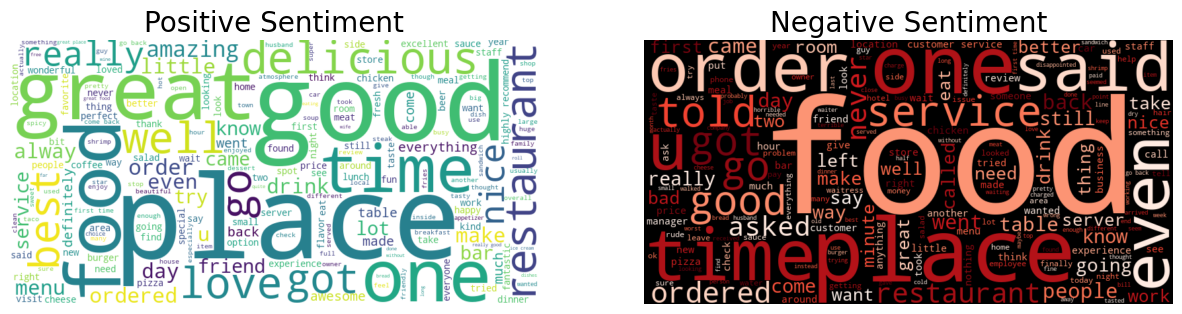

In [381]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import string

# Define stopwords
stop_words = set(stopwords.words('english') + list(string.punctuation))

# Function to preprocess text
def preprocess_text(text):
    tokens = text.lower().split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Filter and preprocess positive reviews
positive_reviews = df[df['stars'] >= 4]['text'].apply(preprocess_text).str.cat(sep=' ')

# Filter and preprocess negative reviews
negative_reviews = df[df['stars'] <= 2]['text'].apply(preprocess_text).str.cat(sep=' ')

# Generate word clouds
positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
negative_wc = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

# Plot word clouds
plt.figure(figsize=(15, 7))

# Positive Word Cloud
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Sentiment', fontsize=20)

# Negative Word Cloud
plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Sentiment', fontsize=20)

plt.show()


In [383]:
from collections import Counter

# Function to get top words
def get_top_words(text, n=10):
    # Tokenize the preprocessed text
    tokens = text.split()
    # Count word frequencies
    word_counts = Counter(tokens)
    # Get the top 'n' most common words
    return word_counts.most_common(n)

# Get top 10 words for positive reviews
top_positive = get_top_words(positive_reviews, n=10)

# Get top 10 words for negative reviews
top_negative = get_top_words(negative_reviews, n=10)

# Display results
print("Top 10 Positive Sentiment Words:")
for word, count in top_positive:
    print(f"{word}: {count}")

print("\nTop 10 Negative Sentiment Words:")
for word, count in top_negative:
    print(f"{word}: {count}")


Top 10 Positive Sentiment Words:
great: 3026
food: 2334
place: 2280
good: 1913
like: 1615
get: 1614
one: 1434
really: 1425
would: 1360
time: 1318

Top 10 Negative Sentiment Words:
food: 1118
would: 1079
get: 1057
like: 983
one: 893
place: 849
time: 751
service: 743
even: 725
back: 716
